In [1]:
!pip -q install datasets sentence-transformers faiss-cpu transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 78.3 MB/s eta 0:00:00


In [9]:
!pip -q install sentence-transformers faiss-cpu

In [10]:
requirements = [
    "read csv file and load into dataframe",
    "train a linear regression model",
    "function to clean missing values",
    "API to fetch user data from database",
    "sort list in descending order",
    "calculate mean and standard deviation",
    "build simple flask api endpoint",
    "convert json to pandas dataframe",
    "write file to disk in python",
    "merge two datasets based on key"
]

codes = [
    "import pandas as pd\ndf = pd.read_csv('file.csv')",
    "from sklearn.linear_model import LinearRegression\nmodel = LinearRegression()",
    "df.fillna(0, inplace=True)",
    "def get_user():\n    return db.query('SELECT * FROM users')",
    "sorted_list = sorted(arr, reverse=True)",
    "import numpy as np\nnp.mean(arr), np.std(arr)",
    "from flask import Flask\napp = Flask(__name__)",
    "import pandas as pd\npd.read_json('data.json')",
    "with open('file.txt','w') as f:\n    f.write(data)",
    "pd.merge(df1, df2, on='id')"
]

print("Dataset ready:", len(requirements))

Dataset ready: 10


In [11]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(requirements, show_progress_bar=True)
print("Embedding shape:", embeddings.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding shape: (10, 384)


In [12]:
import faiss
import numpy as np

dim = embeddings.shape[1]
index = faiss.IndexFlatL2(dim)

index.add(np.array(embeddings))

print("FAISS index built:", index.ntotal)

FAISS index built: 10


In [13]:
def search_code(query, top_k=3):
    q_emb = model.encode([query])
    distances, indices = index.search(np.array(q_emb), top_k)

    results = []
    for i in indices[0]:
        results.append((requirements[i], codes[i]))
    return results

In [14]:
query = "how to load csv in pandas"

results = search_code(query)

for r in results:
    print("\nREQ:", r[0])
    print("CODE:\n", r[1])


REQ: read csv file and load into dataframe
CODE:
 import pandas as pd
df = pd.read_csv('file.csv')

REQ: convert json to pandas dataframe
CODE:
 import pandas as pd
pd.read_json('data.json')

REQ: write file to disk in python
CODE:
 with open('file.txt','w') as f:
    f.write(data)


In [15]:
import numpy as np

def enhanced_search(query, top_k=3):
    query_vec = model.encode([query])

    distances, indices = index.search(np.array(query_vec), top_k)

    results = []

    for rank, idx in enumerate(indices[0]):
        similarity_score = 1 / (1 + distances[0][rank])  # normalize score (0–1)

        results.append({
            "rank": rank + 1,
            "requirement_match": requirements[idx],
            "code": codes[idx],
            "confidence": round(similarity_score, 3)
        })

    return results

In [16]:
query = "convert json file to dataframe"

results = enhanced_search(query)

for r in results:
    print("\n===================")
    print("Rank:", r["rank"])
    print("Confidence:", r["confidence"])
    print("Matched Requirement:", r["requirement_match"])
    print("Code:\n", r["code"])


Rank: 1
Confidence: 0.835
Matched Requirement: convert json to pandas dataframe
Code:
 import pandas as pd
pd.read_json('data.json')

Rank: 2
Confidence: 0.563
Matched Requirement: read csv file and load into dataframe
Code:
 import pandas as pd
df = pd.read_csv('file.csv')

Rank: 3
Confidence: 0.424
Matched Requirement: write file to disk in python
Code:
 with open('file.txt','w') as f:
    f.write(data)


In [19]:
def code_assistant(query):
    results = enhanced_search(query)

    response = {
        "query": query,
        "top_matches": []
    }

    for r in results:
        response["top_matches"].append({
            "rank": int(r["rank"]),
            "confidence": float(r["confidence"]),
            "code_snippet": r["code"]
        })

    return response

In [20]:
import json

query = "how to clean missing values in dataframe"

output = code_assistant(query)

print(json.dumps(output, indent=2))

{
  "query": "how to clean missing values in dataframe",
  "top_matches": [
    {
      "rank": 1,
      "confidence": 0.6110000014305115,
      "code_snippet": "df.fillna(0, inplace=True)"
    },
    {
      "rank": 2,
      "confidence": 0.4650000035762787,
      "code_snippet": "import pandas as pd\npd.read_json('data.json')"
    },
    {
      "rank": 3,
      "confidence": 0.45899999141693115,
      "code_snippet": "import pandas as pd\ndf = pd.read_csv('file.csv')"
    }
  ]
}


In [22]:
def pretty_response(query):
    results = enhanced_search(query)

    print("\n ENTERPRISE AI CODE ASSISTANT\n")
    print("Query:", query)
    print("\nTop Suggestions:\n")

    for r in results:
        print(f"🔹 Rank {r['rank']} | Confidence: {r['confidence']}")
        print("Matched Requirement:", r["requirement_match"])
        print("Code:\n", r["code"])
        print("-" * 50)

In [23]:
pretty_response("train linear regression model in python")


 ENTERPRISE AI CODE ASSISTANT

Query: train linear regression model in python

Top Suggestions:

🔹 Rank 1 | Confidence: 0.6869999766349792
Matched Requirement: train a linear regression model
Code:
 from sklearn.linear_model import LinearRegression
model = LinearRegression()
--------------------------------------------------
🔹 Rank 2 | Confidence: 0.40700000524520874
Matched Requirement: read csv file and load into dataframe
Code:
 import pandas as pd
df = pd.read_csv('file.csv')
--------------------------------------------------
🔹 Rank 3 | Confidence: 0.3930000066757202
Matched Requirement: convert json to pandas dataframe
Code:
 import pandas as pd
pd.read_json('data.json')
--------------------------------------------------


In [24]:
import matplotlib.pyplot as plt

In [25]:
def plot_similarity(query):
    results = enhanced_search(query)

    ranks = [r["rank"] for r in results]
    scores = [r["confidence"] for r in results]

    plt.figure()
    plt.bar(ranks, scores)
    plt.xlabel("Rank")
    plt.ylabel("Similarity Score")
    plt.title(f"Query Similarity: {query}")
    plt.show()

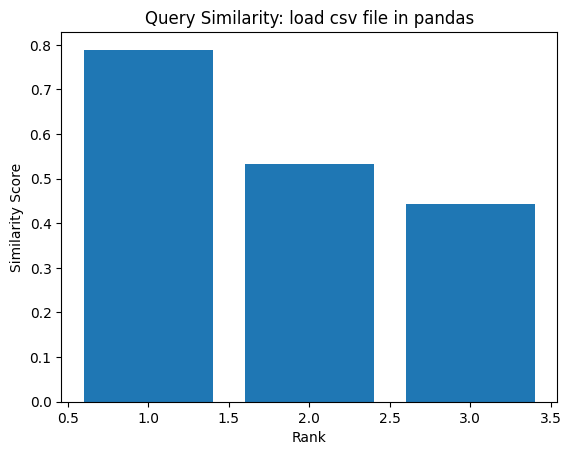

In [26]:
plot_similarity("load csv file in pandas")

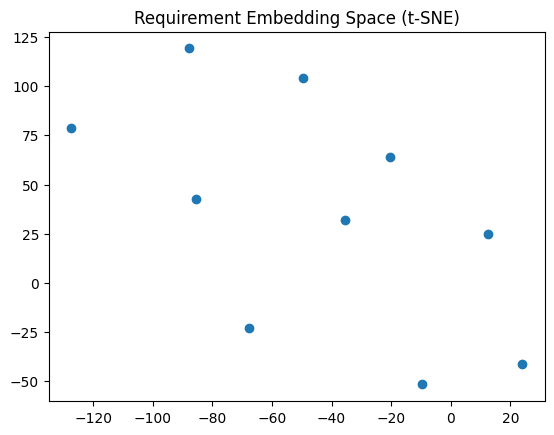

In [33]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

n_samples = embeddings.shape[0]

# safe perplexity rule
perplexity_value = max(2, min(5, n_samples - 1))

tsne = TSNE(
    n_components=2,
    perplexity=perplexity_value,
    random_state=42
)

embeddings_2d = tsne.fit_transform(embeddings)

plt.figure()
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1])
plt.title("Requirement Embedding Space (t-SNE)")
plt.show()

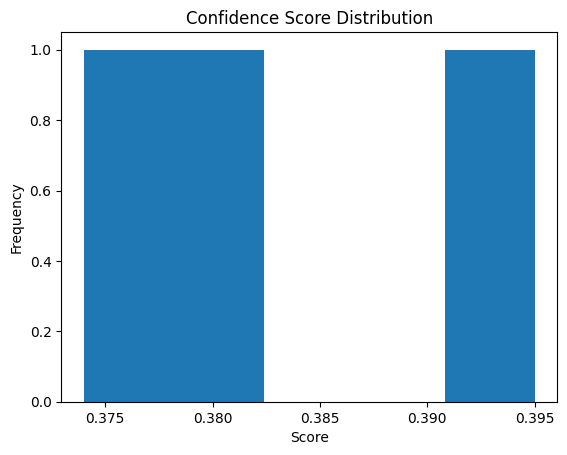

In [30]:
all_scores = [r["confidence"] for r in enhanced_search("test query")]

plt.figure()
plt.hist(all_scores, bins=5)
plt.title("Confidence Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()